# S21 simulation of a resonator

Authors: Sara Buhktari, Christian Kraglund Andersen


In [1]:
# Import useful packages
import qiskit_metal as metal
from qiskit_metal import designs, draw
from qiskit_metal import MetalGUI, Dict, open_docs
from qiskit_metal.toolbox_metal import math_and_overrides
from qiskit_metal.qlibrary.core import QComponent
from collections import OrderedDict

# To create plots after geting solution data.
import matplotlib.pyplot as plt
import numpy as np

# Packages for the simple design
from qiskit_metal.qlibrary.tlines.meandered import RouteMeander
from qiskit_metal.qlibrary.tlines.pathfinder import RoutePathfinder
from qiskit_metal.qlibrary.terminations.launchpad_wb_driven import LaunchpadWirebondDriven
from qiskit_metal.qlibrary.terminations.open_to_ground import OpenToGround
from qiskit_metal.qlibrary.terminations.short_to_ground import ShortToGround

# Analysis
# from qiskit_metal.renderers.renderer_gds.gds_renderer import QGDSRenderer
# from qiskit_metal.analyses.quantization import EPRanalysis
from qiskit_metal.analyses.quantization import EPRanalysis
from qiskit_metal.analyses.simulation import ScatteringImpedanceSim
from qiskit_metal.analyses.sweep_and_optimize.sweeping import Sweeping
import pyEPR as epr

# Set up the design

In [2]:
# Set up chip dimensions 
design = designs.DesignPlanar()
design._chips['main']['size']['size_x'] = '9mm'
design._chips['main']['size']['size_y'] = '9mm'
design._chips['main']['size']['size_z'] = '-525um'

# Resonator and feedline gap width (W) and center conductor width (S) from reference 2
design.variables['cpw_width'] = '10 um' #S from reference 2
design.variables['cpw_gap'] = '6 um' #W from reference 2

design.overwrite_enabled = True

hfss = design.renderers.hfss

# Open GUI
gui = MetalGUI(design)

# Define the geometry

Here we will have a single feedline couple to a single CPW resonator.

The lauchpad should be included in the driven model simulations.

For that reason, we use the LaunchpadWirebondDriven component which has an extra pin for input/output

In [3]:
# Define for renderer
eig_qres = EPRanalysis(design, "hfss")
hfss = design.renderers.hfss
hfss = eig_qres.sim.renderer
q3d = design.renderers.q3d

In [4]:
###################
# Single feedline #
###################

# Driven Lauchpad 1
x = '-1.5mm'
y = '2.0mm'
launch_options = dict(chip='main', pos_x=x, pos_y=y, orientation='360', lead_length='30um')
LP1 = LaunchpadWirebondDriven(design, 'LP1', options = launch_options)

# Driven Launchpad 2
x = '1.5mm'
y = '2.0mm'
launch_options = dict(chip='main', pos_x=x, pos_y=y, orientation='180', lead_length='30um')
LP2 = LaunchpadWirebondDriven(design, 'LP2', options = launch_options)

# Using path finder to connect the two launchpads
TL_LP1_LP2 = RoutePathfinder(design, 'TL_LP1_LP2', options = dict(chip='main', trace_width ='10um',
        trace_gap ='6um', fillet='99um',                                                                  
        hfss_wire_bonds = True, lead=dict(end_straight='1.972mm'), pin_inputs=Dict(
                                                start_pin=Dict(
                                                    component='LP1',
                                                    pin='tie'),
                                                end_pin=Dict(
                                                    component='LP2',
                                                    pin='tie')
                                            )))

# Rebuild the GUI
gui.rebuild()

In [78]:
######################
# lambda/2 resonator #
######################

# First we define the two end-points
otg1 = OpenToGround(design, 'otg1s', options=dict(chip='main', pos_x='-0.3mm',  pos_y='1.97mm', orientation='180'))
# otg1 = OpenToGround(design, 'otg1s', options=dict(chip='main', pos_x='-0.3mm',  pos_y='1.9mm', orientation='180'))
otg2 = OpenToGround(design, 'otg1e', options=dict(chip='main', pos_x='0.0mm',  pos_y='0.0mm', orientation='270'))

# Use RouteMeander to fix the total length of the resonator
rt_meander = RouteMeander(design, 'meander',  Dict(
        trace_width ='10um',
        trace_gap ='6um',
        total_length='8.0mm',
        hfss_wire_bonds = True,
        fillet='99 um',
        lead = dict(start_straight='250um'),
        pin_inputs=Dict(
            start_pin=Dict(component='otg1s', pin='open'),
            end_pin=Dict(component='otg1e', pin='open')), ))

# rebuild the GUI
gui.rebuild()

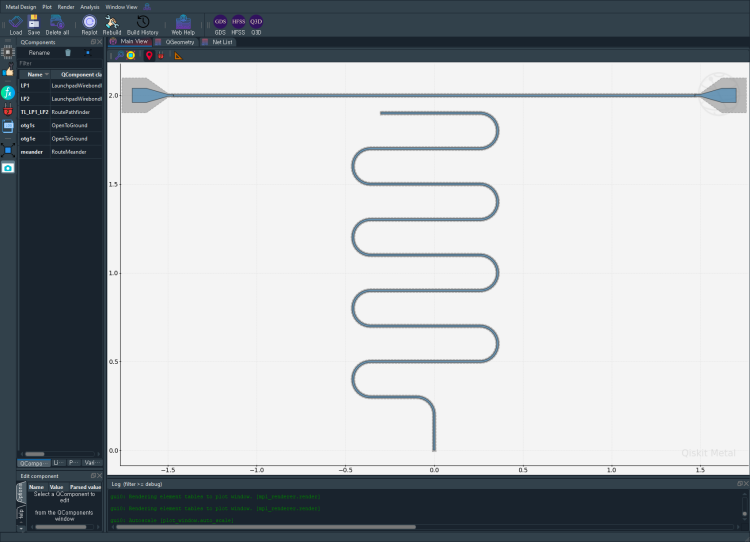

In [63]:
gui.autoscale()
gui.screenshot()

# Scattering Analysis

In [79]:
from qiskit_metal.analyses.simulation import ScatteringImpedanceSim
em1 = ScatteringImpedanceSim(design, "hfss")

In [80]:
design_name= "Sweep_DrivenModal"
qcomp_render = [] # Means to render everything in qgeometry table.
open_terminations = []

# Here, pin LP1_in and LP2_in are converted into lumped ports,
#           each with an impedance of 50 Ohms. <br>
port_list = [('LP1', 'in', 50),
             ('LP2', 'in', 50)]
box_plus_buffer = True

In [81]:
# we use HFSS as rendere
hfss = em1.renderer
hfss.start()

INFO 04:02PM [connect_project]: Connecting to Ansys Desktop API...
INFO 04:02PM [load_ansys_project]: 	Opened Ansys App
INFO 04:02PM [load_ansys_project]: 	Opened Ansys Desktop v2024.2.0


INFO 04:02PM [load_ansys_project]: 	Opened Ansys Project
	Folder:    C:/Users/Jaseung/Documents/Ansoft/
	Project:   Project18
INFO 04:02PM [connect_design]: 	Opened active design
	Design:    HangingResonator [Solution type: HFSS Modal Network]
INFO 04:02PM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.HfssDMSetup'>)
INFO 04:02PM [connect]: 	Connected to project "Project18" and design "HangingResonator" 😀 



True

In [82]:
# Here we activate the design for a drivenmodal solution
hfss.activate_ansys_design("HangingResonator", 'drivenmodal')
setup_args = Dict(max_delta_s=0.001)
setup_args.name = 'Setup'
hfss.edit_drivenmodal_setup(setup_args)

INFO 04:02PM [connect_design]: 	Opened active design
	Design:    HangingResonator [Solution type: HFSS Modal Network]
04:02PM 23s WARNING [activate_ansys_design]: The design_name=HangingResonator already exists, but it has solution_type==hfss modal network, which is different from the requested==drivenmodal. If you want a design with solution type==drivenmodal, please change the name requested for your design to one that does not exist. Alternatively, manually modify the solution_type for design HangingResonator from the Ansys GUI.
04:02PM 23s WARNING [edit_drivenmodal_setup]: The design does not have solution type as "Driven Modal". The Setup not updated.


In [83]:
# set buffer
hfss.options['x_buffer_width_mm'] = 0.1
hfss.options['y_buffer_width_mm'] = 0.1

In [84]:
# clean the design if needed
hfss.clean_active_design()

In [85]:
# render the design
hfss.render_design(selection=[], 
                   open_pins=open_terminations, 
                   port_list=port_list, 
                   box_plus_buffer = box_plus_buffer)

In [86]:
# for acurate simulations, make sure the mesh is fine enough for the meander
hfss.modeler.mesh_length(
                'cpw_mesh',
                ['trace_meander'],
                MaxLength='0.01mm')

# Broad sweet to find the resonance

In [ ]:
sweep_name = "sweep3"
hfss.add_sweep(setup_name="Setup", 
               name=sweep_name, 
               start_ghz=6.0,
               stop_ghz=8.0,
               count=2001,
               type="Fast") # running again will add incrementing number to "Sweep"

INFO 04:02PM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.HfssDMSetup'>)


In [88]:
hfss.analyze_sweep(sweep_name, 'Setup')
# hfss.delete_sweep(sweep_name='Sweep', setup_name="Setup") # This clears sweep not to make a new sweep from hfss.add_sweep

INFO 04:02PM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.HfssDMSetup'>)
INFO 04:02PM [analyze]: Analyzing setup Setup : sweep3


In [89]:
design.chips

{'main': {'material': 'silicon',
  'layer_start': '0',
  'layer_end': '2048',
  'size': {'center_x': '0.0mm',
   'center_y': '0.0mm',
   'center_z': '0.0mm',
   'size_x': '9mm',
   'size_y': '9mm',
   'size_z': '-725um',
   'sample_holder_top': '890um',
   'sample_holder_bottom': '1650um'}}}

In [90]:
# hfss.plot_params(['S11', 'S21'])
hfss.plot_params(['S21'])

(                       S21
 5.0000 -0.573794+0.817714j
 5.0015 -0.573558+0.817879j
 5.0030 -0.573323+0.818043j
 5.0045 -0.573088+0.818207j
 5.0060 -0.572852+0.818372j
 ...                    ...
 7.9940 -0.038771+0.997155j
 7.9955 -0.038484+0.997166j
 7.9970 -0.038198+0.997177j
 7.9985 -0.037911+0.997187j
 8.0000 -0.037625+0.997197j
 
 [2001 rows x 1 columns],
 <Figure size 1000x600 with 2 Axes>)

In [91]:
# extract the S21 parameters
freqs, Pcurves, Pparams = hfss.get_params(['S21'])

In [92]:
# find armin 
f_res = freqs[np.argmin(np.abs(Pparams.S21.values))]
f_res

7110500000.0

# Narrow sweep around the resonance found above

In [58]:
#fine sweep
sweep_name = "sweep_narrow2"
hfss.add_sweep(setup_name="Setup", 
               name=sweep_name, 
               start_ghz=np.round(f_res/1e9,3)-0.01,
               stop_ghz=np.round(f_res/1e9,3)+0.01,
               count=1001,
               type="Fast") #slow but precise

INFO 03:39PM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.HfssDMSetup'>)


In [59]:
hfss.analyze_sweep(sweep_name, 'Setup')

INFO 03:39PM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.HfssDMSetup'>)
INFO 03:39PM [analyze]: Analyzing setup Setup : sweep_narrow2


In [60]:
# hfss.plot_params(['S11', 'S21'])
hfss.plot_params(['S21'])

# find armin 
f_res = freqs[np.argmin(np.abs(Pparams.S21.values))]
f_res

7125500000.0

INFO 03:48PM [__del__]: Disconnected from Ansys HFSS


# Close connections

In [ ]:
em1.close()

In [ ]:
hfss.disconnect_ansys()

In [ ]:
gui.main_window.close()

In [22]:
design.chips

{'main': {'material': 'silicon',
  'layer_start': '0',
  'layer_end': '2048',
  'size': {'center_x': '0.0mm',
   'center_y': '0.0mm',
   'center_z': '0.0mm',
   'size_x': '9mm',
   'size_y': '9mm',
   'size_z': '-750um',
   'sample_holder_top': '890um',
   'sample_holder_bottom': '1650um'}}}